# Customer, Product, and Profitability Analysis
#### APL Logistics (KWE Group)

### 1. Import Libraries

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [383]:
df = pd.read_csv("APL_Logistics.csv", encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


### 3. Data Understanding

In [385]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


Dataset contains ~180k records and 40 columns including sales, profit, customer, and logistics data.

### 4. Data Cleaning & Financial Validation

In [389]:
# Missing values
df.isnull().sum()

# Drop duplicates
df = df.drop_duplicates()

# Remove invalid data
df = df[df['Sales'] > 0]
df = df[df['Order Profit Per Order'] != 0]

# Fill missing values
df = df.fillna(0)

Removed duplicate records and invalid financial entries to ensure accurate analysis.

### 5. Create KPI Columns

In [393]:

df['Profit Margin'] = (df['Order Profit Per Order'] / df['Sales']) * 100
df['Discount Impact'] = df['Order Item Discount'] / df['Sales']

### 6. Revenue & Profit Overview

In [396]:
total_sales = df['Sales'].sum()
total_profit = df['Order Profit Per Order'].sum()
profit_margin = (total_profit / total_sales) * 100

total_sales, total_profit, profit_margin

(36552703.230000004, 3966902.97, 10.852557046298651)

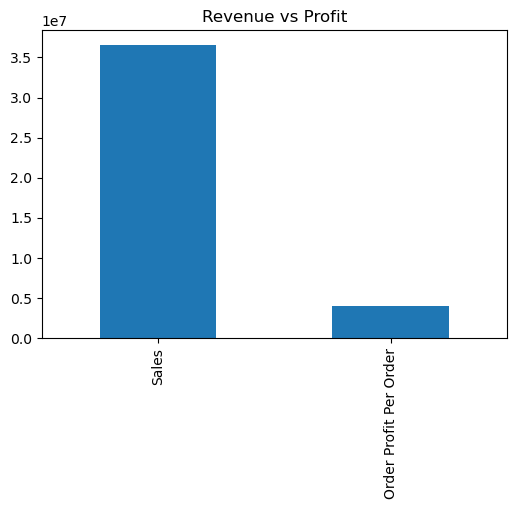

In [399]:
# 📊 Visualization:
df[['Sales', 'Order Profit Per Order']].sum().plot(kind='bar', figsize=(6,4))
plt.title("Revenue vs Profit")
plt.show()

Revenue is high, but profit margin is relatively moderate, indicating inefficiencies.

### 7. Product & Category Profitability Analysis

In [403]:
customer_df = df.groupby('Category Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

category_df['Margin %'] = (
    category_df['Order Profit Per Order'] / category_df['Sales']
) * 100

category_df.sort_values(by='Margin %', ascending=False)
# Loss-making categories
loss_categories = category_df[category_df['Margin %'] < 0]
loss_categories
# High sales but low margin
high_sales_low_margin = category_df[
    (category_df['Sales'] > category_df['Sales'].mean()) &
    (category_df['Margin %'] < category_df['Margin %'].mean())
]

high_sales_low_margin

,Category Name,Sales,Order Profit Per Order,Margin %
9,Camping & Hiking,4091727.20,427455.57,10.446825
10,Cardio Equipment,3669885.66,383011.10,10.436595
38,Shop By Sport,1300744.17,129813.96,9.979976
46,Water Sports,3095645.51,325146.96,10.503365


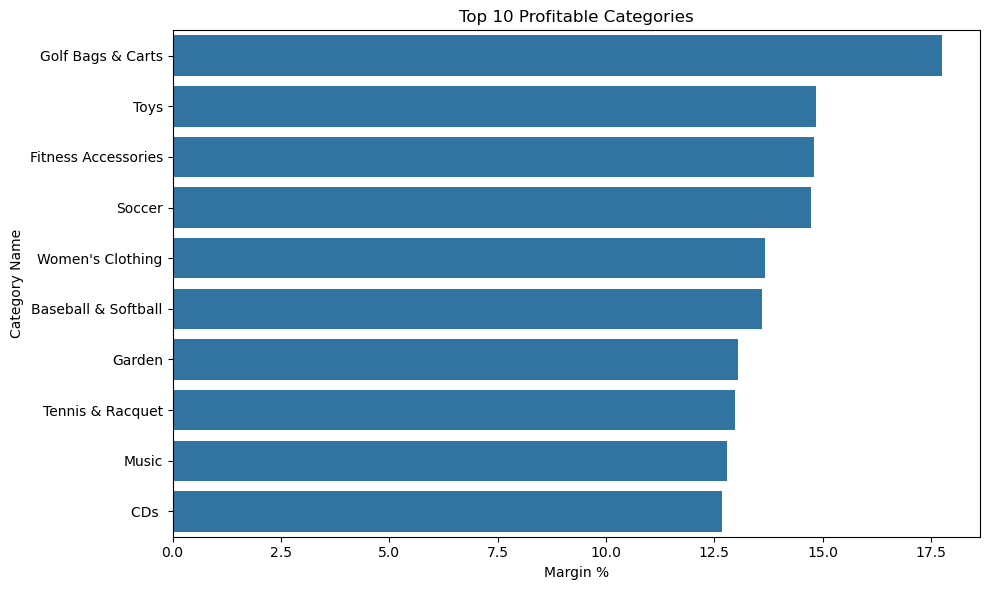

In [405]:
# 📊 Visualization:
top_categories = category_df.sort_values(
    by='Margin %', ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_categories,
    x='Margin %',
    y='Category Name'
)

plt.title("Top 10 Profitable Categories")
plt.tight_layout()
plt.show()

- Top categories show higher profitability, while some categories have lower margins.
- Certain categories generate high revenue but have low profit margins, indicating pricing or cost issues.

### 8. Customer Contribution Analysis

In [457]:
customer_df = df.groupby('Customer Id').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

customer_df = customer_df.sort_values(by='Order Profit Per Order', ascending=False)

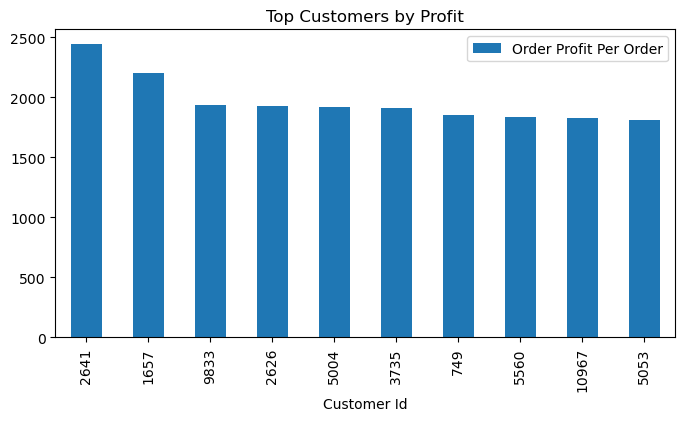

In [459]:
# 📊 Chart
customer_df.head(10).plot(
    x='Customer Id',
    y='Order Profit Per Order',
    kind='bar',
    figsize=(8,4)
)
plt.title("Top Customers by Profit")
plt.show()

### 9. Customer Segmentation

In [452]:
customer_df['Segment'] = pd.qcut(
    customer_df['Order Profit Per Order'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_df['Segment'].value_counts()

Segment
Medium Value    6867
Low Value       6866
High Value      6866
Name: count, dtype: int64

- A small group of customers contributes most of the profit
- Some customers generate losses despite high sales

### 10. Discount Impact Diagnostics

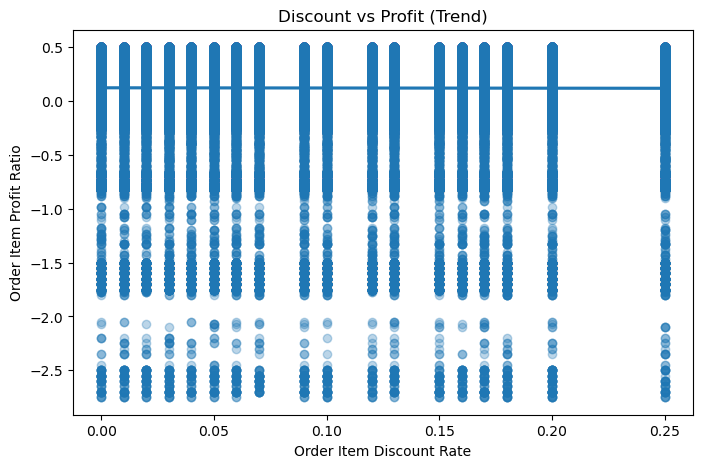

In [418]:
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Order Item Discount Rate'],
    y=df['Order Item Profit Ratio'],
    scatter_kws={'alpha':0.3}
)

plt.title("Discount vs Profit (Trend)")
plt.show()

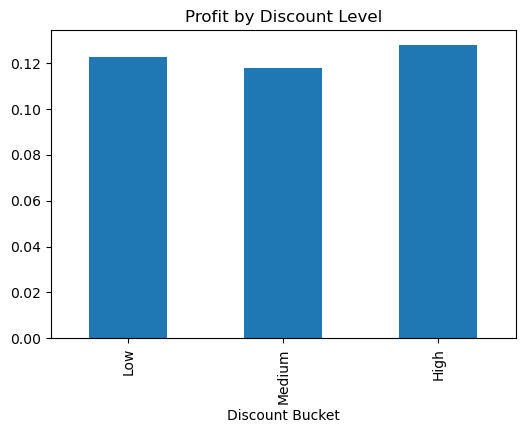

In [419]:
# Discount threshold analysis
df['Discount Bucket'] = pd.cut(
    df['Order Item Discount Rate'],
    bins=[0, 0.1, 0.2, 0.3],
    labels=['Low', 'Medium', 'High']
)

discount_analysis = df.groupby('Discount Bucket', observed=True)['Order Item Profit Ratio'].mean()
discount_analysis
discount_analysis.plot(kind='bar', figsize=(6,4))
plt.title("Profit by Discount Level")
plt.show()

In [420]:
discount_analysis_full = df.groupby('Discount Bucket', observed=True).agg({
    'Order Item Profit Ratio': 'mean',
    'Sales': 'count'
})

discount_analysis_full

,Order Item Profit Ratio,Sales
Discount Bucket,,
Low,0.122558,89660
Medium,0.118070,69764
High,0.127949,9967


#### Discount Impact Analysis

- Medium discount levels show the lowest profitability, indicating inefficient pricing strategies.
- High discount transactions appear profitable but occur at a much lower volume.
- Low discount levels contribute the majority of orders with stable profit margins.
- This suggests that excessive discounting is not consistently beneficial and must be applied strategically.

### 11. Market & Regional Profit Analysis

In [423]:
region_df = df.groupby('Order Region').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()


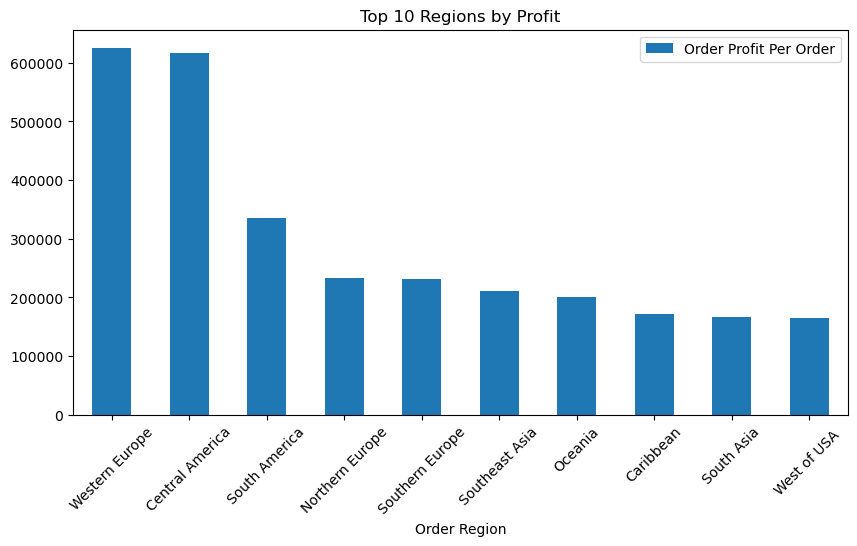

In [424]:
# 📊 Visualization:
top_regions = region_df.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

top_regions.plot(
    x='Order Region',
    y='Order Profit Per Order',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Regions by Profit")
plt.xticks(rotation=45)
plt.show()

- Some regions show strong revenue but weak profitability
- Indicates operational inefficiencies or high costs

### 12. Key Performance Indicators (KPIs)

In [427]:
# 12. KPI Summary
# Customer Value Index
customer_value = df.groupby('Customer Id')['Order Profit Per Order'].sum()
customer_value_index = customer_value.mean()

# Category Margin
category_df = df.groupby('Category Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

category_df['Margin %'] = (
    category_df['Order Profit Per Order'] / category_df['Sales']
) * 100

category_margin = category_df['Margin %'].mean()

# Discount Impact Ratio
discount_impact_ratio = (
    df['Order Item Discount'].sum() / df['Sales'].sum()
) * 100

# KPI Dictionary
kpi = {
    "Total Revenue": df['Sales'].sum(),
    "Total Profit": df['Order Profit Per Order'].sum(),
    "Profit Margin (%)": (df['Order Profit Per Order'].sum() / df['Sales'].sum()) * 100,
    "Customer Value Index": customer_value_index,
    "Category Margin (%)": category_margin,
    "Discount Impact Ratio (%)": discount_impact_ratio
}

kpi

{'Total Revenue': 36552703.230000004,
 'Total Profit': 3966902.97,
 'Profit Margin (%)': 10.852557046298651,
 'Customer Value Index': 192.57745375989126,
 'Category Margin (%)': 10.832291048558007,
 'Discount Impact Ratio (%)': 10.144102466700106}

#### KPI Insights

- The company generated total revenue of 36.55M with a profit of 3.96M.
- Profit margin is approximately 10.85%, indicating moderate efficiency.
- Customer Value Index (~192) shows strong average profit per customer.
- Category Margin (~10.83%) suggests consistent profitability across products.
- Discount Impact (~10.14%) indicates discounts significantly affect margins.

In [429]:
pd.DataFrame(list(kpi.items()), columns=['KPI', 'Value'])

,KPI,Value
0,Total Revenue,3.655270e+07
1,Total Profit,3.966903e+06
2,Profit Margin (%),1.085256e+01
3,Customer Value Index,1.925775e+02
4,Category Margin (%),1.083229e+01
5,Discount Impact Ratio (%),1.014410e+01


# 13. Final Insights & Recommendations

## Key Insights

- High revenue does not guarantee high profit
- Discounts significantly reduce profitability
- Few customers contribute majority of profit
- Some categories have lower margins
- Regional performance varies significantly

## Recommendations

- Optimize discount strategies
- Focus on high-value customers
- Improve pricing for low-margin products
- Strengthen operations in weak regions

In [ ]:
df.to_csv("APL_Logistics_Cleaned.csv", index=False)